In [1]:
import pandas as pd

df = pd.read_csv('./SMSSpamCollection.csv', sep ='\t')

In [2]:
df['target'] = df['target'].apply(lambda x: 1 if x=='spam' else 0)

In [3]:
############################################
#Verificação do percentual de balancamento:#
#(i) Fazer agrupamento pelo target         #
#(ii) Contar o toal do agrupamento.        #
#(iii) Cálculo da porcentagem.             #
############################################

contagem_classes = df.groupby('target')['target'].count()

total = contagem_classes.sum()

porcentagem_classes = contagem_classes / total *100
print(porcentagem_classes)


target
0    86.593683
1    13.406317
Name: target, dtype: float64


In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
# X representação do feature space (espaço de características)
X = df['text']
# y representação do target (a verdade - a base é supervisionada)
y= df['target']
# O método train_test_split recebe de parâmetro:
#(i) X -> Espaço de características
#(ii) y-> target (a verdade ex: se é ou não é spam)
#(iii) test_size -> porcentagem daquilo que será separado para teste, no caso 25% de todas as instâncias (instância é uma linha da base de dados).
#(iv) random_state -> é a seed (semente) para a geração do sorteio das instâncias.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
# O método train_test_split retorna 4 variáveis:
#(i) X_train -> espaço de caracterísricas de treinamento - instâncias sorteadas de treinamento (75% da base)
#(i) X_test -> espaço de caracterísricas de teste - instâncias sorteadas de teste (25% da base)
#(ii) y_train -> target de treinamento -  instâncias sorteadas de treinamento (75% da base)
#(iii)y_test ->  target de teste -  instâncias sorteadas de teste (25% da base)

In [5]:
# Importando a biblioteca do TF-IDF, que fará o processo de contagem de palavras (bag-of-words)
from sklearn.feature_extraction.text import TfidfVectorizer

# Pegando os índices de treimaneto e teste
X_train_indices = X_train.index  # Índices sorteados para treinamento
X_test_indices = X_test.index    # Índices sorteados para teste

# Localizando o texto através dos índices com iloc
X_train_text = df['text'].iloc[X_train_indices] # Extraindo o texto correspondente aos índices presentes no treinamento
X_test_text = df['text'].iloc[X_test_indices]   # Extraindo o texto correspondente aos índices presentes no teste

# Incializando o TfidfVectorizer com parâmtros default (padrão)
vectorizer = TfidfVectorizer(token_pattern=r'\b[A-Za-zÀ-ÿ]+\b')
#Atributo (no caso de texto)-> Uma nova palavra a ser contada
# No espaço de características (texto) de treimaneto, apenas dar "fit_transform", ou seja a irá ser criado os atributos TF-IDF através do FIT e irá ser feita a contagem de palavras através do Transform.
X_train_tfidf = vectorizer.fit_transform(X_train_text)
# No espaço de características (texto) de treimaneto, apenas dar apenas "transform", não criando nenhum atributo novo, apenas contando os atributos já criandos anteriormente.
X_test_tfidf = vectorizer.transform(X_test_text)

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

vectorizer = TfidfVectorizer(
    token_pattern=r"\b[A-Za-zÀ-ÿ]+\b",
    max_features=500,
    ngram_range=(1, 2), 
    use_idf= True
)

# Calculando o TF-IDF
X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

# Obtendo as palavras escolhidas
palavras = vectorizer.get_feature_names_out()

# Criando os DataFrames com as palavras como colunas
X_train_tfidf_df = pd.DataFrame.sparse.from_spmatrix(
    X_train_tfidf,
    index=X_train_text.index,
    columns=palavras
)

X_test_tfidf_df = pd.DataFrame.sparse.from_spmatrix(
    X_test_tfidf,
    index=X_test_text.index,
    columns=palavras
)

In [7]:
X_train_tfidf_df

,a,a bit,a good,a great,about,after,again,ah,aight,all,...,you have,you i,you in,you know,you re,you want,your,your mobile,yup,ü
4281,0.139722,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.269158,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
585,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.171168,NaN,NaN,NaN
4545,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3034,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.611504,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2758,0.2825,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,0.159136,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5191,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5226,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Modelo-base
# n_jobs=1 evita paralelismo duplicado dentro de cada treinamento
modelo_base = RandomForestClassifier(
    random_state=42,
    n_jobs=1
)

# Valores que serão testados
parametros = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [None, 10, 20, 30, 50],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.3, 0.5],
    "class_weight": [None, "balanced", "balanced_subsample"],
    "criterion": ["gini", "entropy"]
}

# Validação cruzada estratificada
validacao = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Busca aleatória dos melhores hiperparâmetros
busca = RandomizedSearchCV(
    estimator=modelo_base,
    param_distributions=parametros,
    n_iter=30,
    scoring="f1",       # classe positiva = 1 (spam)
    cv=validacao,
    refit=True,
    n_jobs=-1,          # utiliza todos os núcleos disponíveis
    verbose=2,
    random_state=42,
    error_score="raise"
)

# Realizando a busca somente com os dados de treinamento
busca.fit(X_train_tfidf, y_train)

# O melhor modelo já retorna treinado
melhor_modelo = busca.best_estimator_

# Usa paralelismo nas previsões posteriores
melhor_modelo.set_params(n_jobs=-1)

print("\nMelhores hiperparâmetros:")
print(busca.best_params_)

print(f"\nMelhor F1 médio na validação: {busca.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Melhores hiperparâmetros:
{'n_estimators': 700, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 50, 'criterion': 'entropy', 'class_weight': 'balanced'}

Melhor F1 médio na validação: 0.9306



 # Quantidade de árvores de decisão que formarão a floresta.
    #
    # O modelo treinará 700 árvores diferentes. Cada árvore é construída
    # usando uma amostra aleatória dos dados e diferentes subconjuntos de
    # atributos. A previsão final é obtida pela combinação das previsões
    # dessas 700 árvores.
    #
    # Em uma classificação, cada árvore fornece uma probabilidade para
    # cada classe, e a floresta calcula a média dessas probabilidades.
    #
    # Uma quantidade maior de árvores normalmente deixa o resultado mais
    # estável e reduz a variância, mas aumenta o tempo de treinamento,
    # o tempo de previsão e o consumo de memória.
    n_estimators=700,

    # Quantidade mínima de amostras que um nó deve possuir para que o
    # algoritmo tente dividi-lo em dois novos nós.
    #
    # Com o valor 10, um nó que possuir 10 ou mais amostras poderá ser
    # dividido. Um nó com menos de 10 amostras não poderá mais ser dividido
    # e será transformado em uma folha.
    #
    # Esse parâmetro ajuda a limitar divisões baseadas em poucos exemplos,
    # reduzindo a possibilidade de sobreajuste.
    min_samples_split=10,

    # Quantidade mínima de amostras permitida em cada folha da árvore.
    #
    # Com o valor 1, uma folha pode conter apenas uma amostra. Isso permite
    # que a árvore represente padrões muito específicos dos dados.
    #
    # Valores maiores produzem folhas mais gerais e podem reduzir o
    # sobreajuste, mas também podem impedir que o modelo aprenda padrões
    # raros associados a mensagens de spam.
    #
    # Mesmo que um nó possua as 10 amostras exigidas por min_samples_split,
    # uma divisão somente será aceita se cada folha resultante possuir
    # pelo menos 1 amostra.
    min_samples_leaf=1,

    # Número de atributos considerados aleatoriamente em cada tentativa
    # de divisão de um nó.
    #
    # O valor "sqrt" significa que será usada a raiz quadrada do total de
    # atributos disponíveis. Se o TF-IDF tiver 500 termos, cada divisão
    # avaliará aproximadamente:
    #
    # sqrt(500) = 22 atributos
    #
    # Cada nó pode receber um subconjunto diferente de palavras. Isso
    # aumenta a diversidade entre as árvores e reduz a correlação entre
    # elas, uma característica central do Random Forest.
    max_features="sqrt",

    # Profundidade máxima permitida para cada árvore.
    #
    # Com o valor 50, uma árvore poderá ter no máximo 50 níveis de divisão,
    # contando o caminho entre o nó inicial e uma folha.
    #
    # A árvore pode terminar antes de chegar ao nível 50 quando:
    # - o nó já contém apenas exemplos da mesma classe;
    # - não existe uma divisão que melhore o critério;
    # - o nó não possui as 10 amostras exigidas por min_samples_split;
    # - outra restrição da árvore impede uma nova divisão.
    #
    # Limitar a profundidade ajuda a controlar o tamanho das árvores,
    # o consumo de memória e o sobreajuste.
    max_depth=50,

    # Medida usada para decidir qual divisão separa melhor as classes.
    #
    # "entropy" utiliza a entropia de Shannon. O algoritmo procura a
    # divisão que produz a maior redução de entropia, também chamada de
    # ganho de informação.
    #
    # Um nó apresenta entropia baixa quando contém principalmente exemplos
    # de uma única classe. A entropia é maior quando existe uma mistura
    # mais equilibrada entre ham e spam.
    #
    # Assim, o algoritmo favorece divisões que criem grupos mais puros.
    criterion="entropy",

    # Ajusta automaticamente a importância das classes conforme a
    # frequência delas no conjunto de treinamento.
    #
    # Como normalmente existem muito mais mensagens ham do que spam, o
    # valor "balanced" atribui um peso maior aos exemplos de spam e um peso
    # menor aos exemplos de ham.
    #
    # O peso de cada classe é calculado aproximadamente por:
    #
    # número total de amostras
    # ------------------------------------------------
    # número de classes × amostras existentes na classe
    #
    # Esses pesos influenciam o cálculo da entropia e a escolha das
    # divisões. Com isso, errar uma mensagem da classe minoritária, spam,
    # recebe uma penalização maior durante o treinamento.
    class_weight="balanced",

    # Garante que os sorteios internos sejam reproduzíveis. Ao executar
    # novamente com os mesmos dados, o modelo produzirá o mesmo resultado.
    random_state=42,

    # Utiliza todos os núcleos disponíveis para treinar as árvores e
    # realizar previsões.
    n_jobs=-1 # Quantidade de árvores de decisão que formarão a floresta.
    #
    # O modelo treinará 700 árvores diferentes. Cada árvore é construída
    # usando uma amostra aleatória dos dados e diferentes subconjuntos de
    # atributos. A previsão final é obtida pela combinação das previsões
    # dessas 700 árvores.
    #
    # Em uma classificação, cada árvore fornece uma probabilidade para
    # cada classe, e a floresta calcula a média dessas probabilidades.
    #
    # Uma quantidade maior de árvores normalmente deixa o resultado mais
    # estável e reduz a variância, mas aumenta o tempo de treinamento,
    # o tempo de previsão e o consumo de memória.
    n_estimators=700,

    # Quantidade mínima de amostras que um nó deve possuir para que o
    # algoritmo tente dividi-lo em dois novos nós.
    #
    # Com o valor 10, um nó que possuir 10 ou mais amostras poderá ser
    # dividido. Um nó com menos de 10 amostras não poderá mais ser dividido
    # e será transformado em uma folha.
    #
    # Esse parâmetro ajuda a limitar divisões baseadas em poucos exemplos,
    # reduzindo a possibilidade de sobreajuste.
    min_samples_split=10,

    # Quantidade mínima de amostras permitida em cada folha da árvore.
    #
    # Com o valor 1, uma folha pode conter apenas uma amostra. Isso permite
    # que a árvore represente padrões muito específicos dos dados.
    #
    # Valores maiores produzem folhas mais gerais e podem reduzir o
    # sobreajuste, mas também podem impedir que o modelo aprenda padrões
    # raros associados a mensagens de spam.
    #
    # Mesmo que um nó possua as 10 amostras exigidas por min_samples_split,
    # uma divisão somente será aceita se cada folha resultante possuir
    # pelo menos 1 amostra.
    min_samples_leaf=1,

    # Número de atributos considerados aleatoriamente em cada tentativa
    # de divisão de um nó.
    #
    # O valor "sqrt" significa que será usada a raiz quadrada do total de
    # atributos disponíveis. Se o TF-IDF tiver 500 termos, cada divisão
    # avaliará aproximadamente:
    #
    # sqrt(500) = 22 atributos
    #
    # Cada nó pode receber um subconjunto diferente de palavras. Isso
    # aumenta a diversidade entre as árvores e reduz a correlação entre
    # elas, uma característica central do Random Forest.
    max_features="sqrt",

    # Profundidade máxima permitida para cada árvore.
    #
    # Com o valor 50, uma árvore poderá ter no máximo 50 níveis de divisão,
    # contando o caminho entre o nó inicial e uma folha.
    #
    # A árvore pode terminar antes de chegar ao nível 50 quando:
    # - o nó já contém apenas exemplos da mesma classe;
    # - não existe uma divisão que melhore o critério;
    # - o nó não possui as 10 amostras exigidas por min_samples_split;
    # - outra restrição da árvore impede uma nova divisão.
    #
    # Limitar a profundidade ajuda a controlar o tamanho das árvores,
    # o consumo de memória e o sobreajuste.
    max_depth=50,

    # Medida usada para decidir qual divisão separa melhor as classes.
    #
    # "entropy" utiliza a entropia de Shannon. O algoritmo procura a
    # divisão que produz a maior redução de entropia, também chamada de
    # ganho de informação.
    #
    # Um nó apresenta entropia baixa quando contém principalmente exemplos
    # de uma única classe. A entropia é maior quando existe uma mistura
    # mais equilibrada entre ham e spam.
    #
    # Assim, o algoritmo favorece divisões que criem grupos mais puros.
    criterion="entropy",

    # Ajusta automaticamente a importância das classes conforme a
    # frequência delas no conjunto de treinamento.
    #
    # Como normalmente existem muito mais mensagens ham do que spam, o
    # valor "balanced" atribui um peso maior aos exemplos de spam e um peso
    # menor aos exemplos de ham.
    #
    # O peso de cada classe é calculado aproximadamente por:
    #
    # número total de amostras
    # ------------------------------------------------
    # número de classes × amostras existentes na classe
    #
    # Esses pesos influenciam o cálculo da entropia e a escolha das
    # divisões. Com isso, errar uma mensagem da classe minoritária, spam,
    # recebe uma penalização maior durante o treinamento.
    class_weight="balanced",

    # Garante que os sorteios internos sejam reproduzíveis. Ao executar
    # novamente com os mesmos dados, o modelo produzirá o mesmo resultado.
    random_state=42,

    # Utiliza todos os núcleos disponíveis para treinar as árvores e
    # realizar previsões.
    n_jobs=-1

C:\Users\arthu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


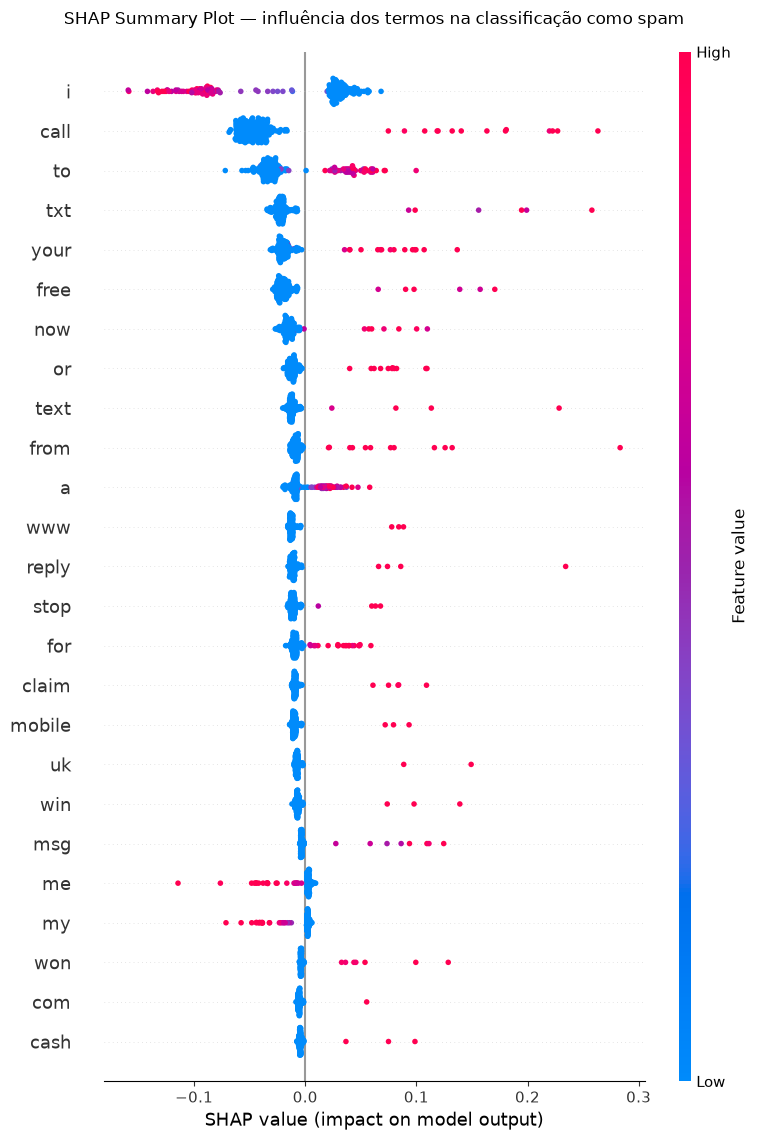

In [10]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# O cálculo do SHAP pode ser demorado para 700 árvores.
# Por isso, usamos uma amostra aleatória de até 200 mensagens de teste.
quantidade_amostras = min(200, X_test_tfidf.shape[0])

gerador = np.random.default_rng(42)

indices_shap = gerador.choice(
    X_test_tfidf.shape[0],
    size=quantidade_amostras,
    replace=False
)

# Seleciona as mensagens sorteadas.
X_shap_matriz = X_test_tfidf[indices_shap]

# O Random Forest e o SHAP trabalham melhor nesta etapa com uma matriz densa.
X_shap_array = X_shap_matriz.toarray()

# Recupera os unigramas e bigramas usados pelo TF-IDF.
nomes_atributos = vectorizer.get_feature_names_out()

# Cria um DataFrame para que as palavras apareçam no gráfico.
X_shap = pd.DataFrame(
    X_shap_array,
    columns=nomes_atributos
)

# Cria o explicador específico para modelos baseados em árvores.
explainer = shap.TreeExplainer(melhor_modelo)

# Calcula os valores SHAP.
valores_shap = explainer(
    X_shap,
    check_additivity=True
)

# Localiza a posição da classe positiva 1, correspondente a spam.
indice_classe_spam = list(melhor_modelo.classes_).index(1)

# Em classificações binárias, o SHAP pode produzir uma dimensão
# separada para cada classe. Selecionamos somente a classe spam.
if valores_shap.values.ndim == 3:
    valores_spam = valores_shap.values[:, :, indice_classe_spam]
else:
    valores_spam = valores_shap.values

# Cria o SHAP Summary Plot.
shap.summary_plot(
    valores_spam,
    X_shap,
    feature_names=nomes_atributos,
    plot_type="dot",
    max_display=25,
    show=False
)

plt.title(
    "SHAP Summary Plot — influência dos termos na classificação como spam",
    pad=20
)

plt.tight_layout()
plt.show()

Métricas do conjunto de teste:


,Métrica,Valor
0,Acurácia,0.9864
1,Precisão,0.9771
2,Recall,0.9194
3,F1-score,0.9474
4,ROC-AUC,0.9924
5,AUC-PR,0.9795


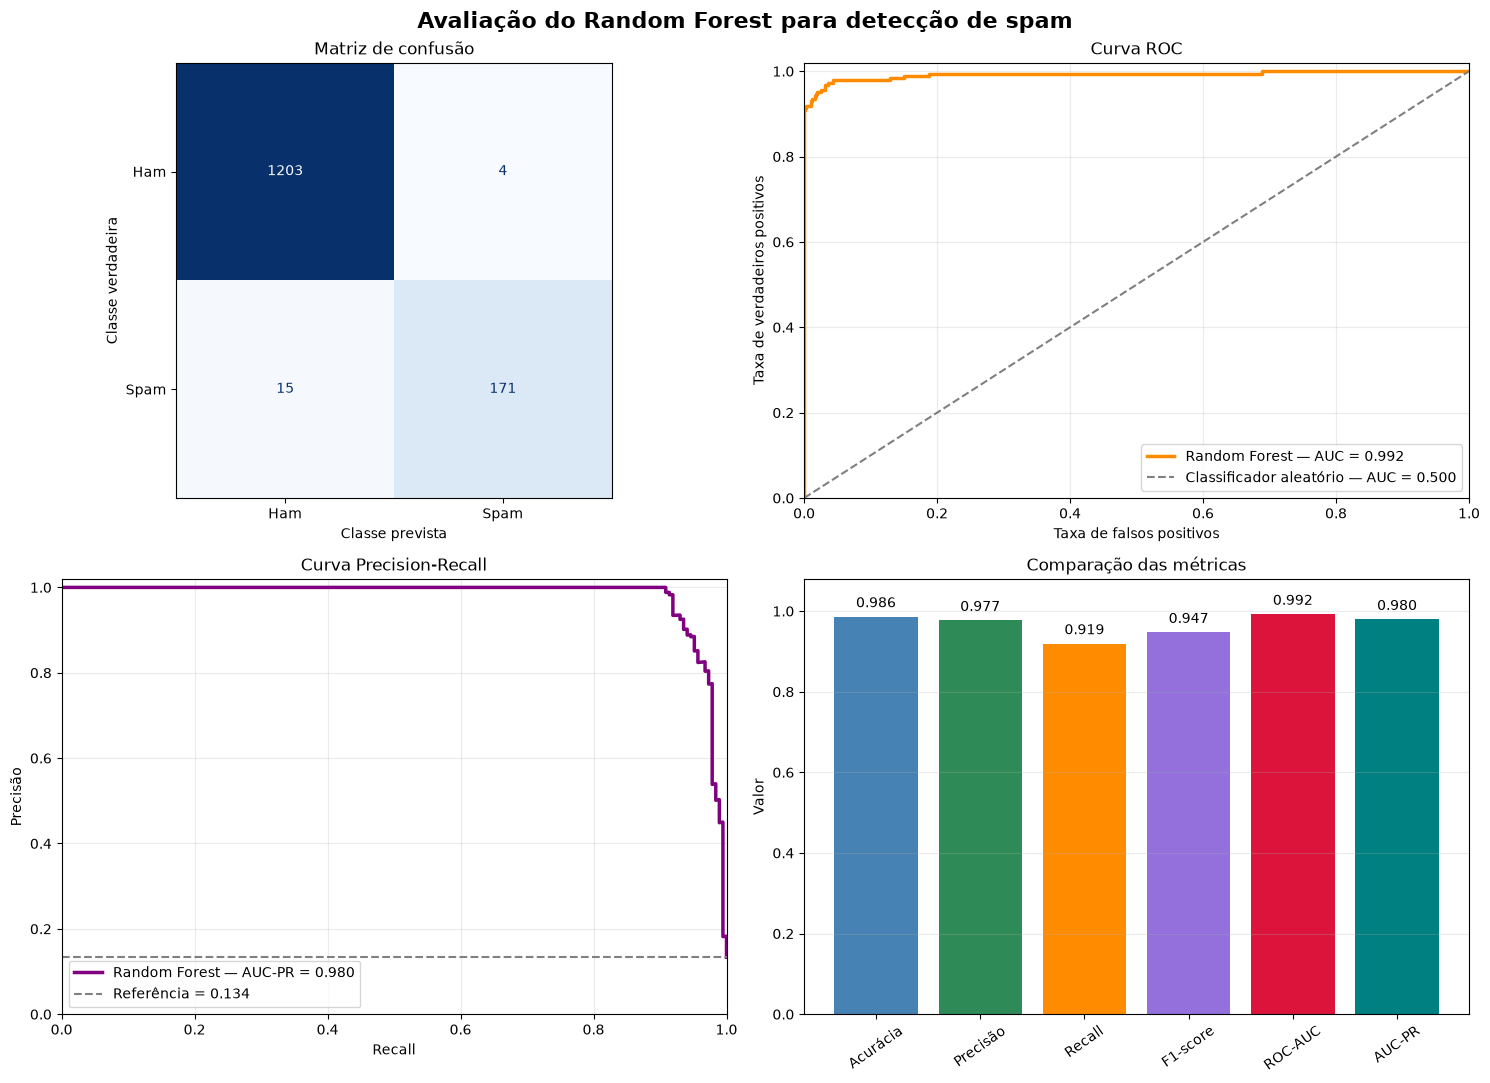

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc,
    ConfusionMatrixDisplay
)

# ---------------------------------------------------------
# 1. Realizando as previsões
# ---------------------------------------------------------

# Classes previstas usando o limiar padrão do modelo.
y_pred = melhor_modelo.predict(X_test_tfidf)

# Descobre em qual coluna do predict_proba está a classe spam (classe 1).
indice_spam = list(melhor_modelo.classes_).index(1)

# Probabilidade de cada mensagem pertencer à classe spam.
# As probabilidades são necessárias para calcular ROC-AUC e AUC-PR.
y_prob_spam = melhor_modelo.predict_proba(X_test_tfidf)[:, indice_spam]


# ---------------------------------------------------------
# 2. Calculando as métricas
# ---------------------------------------------------------

acuracia = accuracy_score(y_test, y_pred)

# pos_label=1 informa que spam é a classe positiva.
precisao = precision_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0
)

revocacao = recall_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0
)

# Área sob a curva ROC.
roc_auc = roc_auc_score(
    y_test,
    y_prob_spam
)

# Pontos usados para construir a curva Precision-Recall.
precisoes_curva, revocacoes_curva, limiares_pr = precision_recall_curve(
    y_test,
    y_prob_spam,
    pos_label=1
)

# Área sob a curva Precision-Recall usando integração trapezoidal.
auc_pr = auc(
    revocacoes_curva,
    precisoes_curva
)

metricas = pd.DataFrame({
    "Métrica": [
        "Acurácia",
        "Precisão",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "AUC-PR"
    ],
    "Valor": [
        acuracia,
        precisao,
        revocacao,
        f1,
        roc_auc,
        auc_pr
    ]
})

print("Métricas do conjunto de teste:")
display(
    metricas.style.format({"Valor": "{:.4f}"})
)


# ---------------------------------------------------------
# 3. Preparando as curvas
# ---------------------------------------------------------

fpr, tpr, limiares_roc = roc_curve(
    y_test,
    y_prob_spam,
    pos_label=1
)

# Proporção de spam no teste.
# Representa a linha de referência da curva Precision-Recall.
proporcao_spam = np.mean(np.asarray(y_test) == 1)


# ---------------------------------------------------------
# 4. Desenhando os gráficos
# ---------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(15, 11)
)

# Gráfico 1: matriz de confusão
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=[0, 1],
    display_labels=["Ham", "Spam"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 0]
)

axes[0, 0].set_title("Matriz de confusão")
axes[0, 0].set_xlabel("Classe prevista")
axes[0, 0].set_ylabel("Classe verdadeira")


# Gráfico 2: curva ROC
axes[0, 1].plot(
    fpr,
    tpr,
    linewidth=2.5,
    color="darkorange",
    label=f"Random Forest — AUC = {roc_auc:.3f}"
)

axes[0, 1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Classificador aleatório — AUC = 0.500"
)

axes[0, 1].set_title("Curva ROC")
axes[0, 1].set_xlabel("Taxa de falsos positivos")
axes[0, 1].set_ylabel("Taxa de verdadeiros positivos")
axes[0, 1].set_xlim(0, 1)
axes[0, 1].set_ylim(0, 1.02)
axes[0, 1].grid(alpha=0.25)
axes[0, 1].legend(loc="lower right")


# Gráfico 3: curva Precision-Recall
axes[1, 0].plot(
    revocacoes_curva,
    precisoes_curva,
    linewidth=2.5,
    color="purple",
    label=f"Random Forest — AUC-PR = {auc_pr:.3f}"
)

axes[1, 0].axhline(
    proporcao_spam,
    linestyle="--",
    color="gray",
    label=f"Referência = {proporcao_spam:.3f}"
)

axes[1, 0].set_title("Curva Precision-Recall")
axes[1, 0].set_xlabel("Recall")
axes[1, 0].set_ylabel("Precisão")
axes[1, 0].set_xlim(0, 1)
axes[1, 0].set_ylim(0, 1.02)
axes[1, 0].grid(alpha=0.25)
axes[1, 0].legend(loc="lower left")


# Gráfico 4: comparação das métricas
cores = [
    "steelblue",
    "seagreen",
    "darkorange",
    "mediumpurple",
    "crimson",
    "teal"
]

barras = axes[1, 1].bar(
    metricas["Métrica"],
    metricas["Valor"],
    color=cores
)

axes[1, 1].set_title("Comparação das métricas")
axes[1, 1].set_ylabel("Valor")
axes[1, 1].set_ylim(0, 1.08)
axes[1, 1].tick_params(axis="x", rotation=35)
axes[1, 1].grid(axis="y", alpha=0.25)

# Escreve o valor acima de cada barra.
for barra, valor in zip(barras, metricas["Valor"]):
    axes[1, 1].text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.015,
        f"{valor:.3f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

fig.suptitle(
    "Avaliação do Random Forest para detecção de spam",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def plot_histogram(y_true, y_prob, threshold=0.5, bins=25, class_labels=("Classe 0", "Classe 1")):
    y_true = np.asarray(y_true)
    y_prob_pct = np.asarray(y_prob) * 100
    threshold_pct = threshold * 100
    total_instancias = len(y_prob_pct)

    bin_edges = np.linspace(0, 100, bins + 1)
    contagem_0, _ = np.histogram(y_prob_pct[y_true == 0], bins=bin_edges)
    contagem_1, _ = np.histogram(y_prob_pct[y_true == 1], bins=bin_edges)

    # percentual sobre o TOTAL do conjunto avaliado (as duas classes juntas), não por classe
    pct_0 = contagem_0 / total_instancias * 100
    pct_1 = contagem_1 / total_instancias * 100

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.step(bin_edges[:-1], pct_0, where="post", color="#3b6fd4", linewidth=2, label=class_labels[0])
    ax.step(bin_edges[:-1], pct_1, where="post", color="#d9622b", linewidth=2, label=class_labels[1])

    ax.axvline(threshold_pct, color="black", linestyle="--", linewidth=1.5, label=f"Threshold = {threshold_pct:.0f}%")
    ax.set_xlabel("Probabilidade estimada da classe positiva (%)")
    ax.set_ylabel("Instâncias do conjunto avaliado (%)")
    ax.set_title("Distribuição das probabilidades previstas por classe real")
    ax.set_xlim(0, 100)
    ax.legend()
    plt.tight_layout()
    plt.show()

    return fig, ax

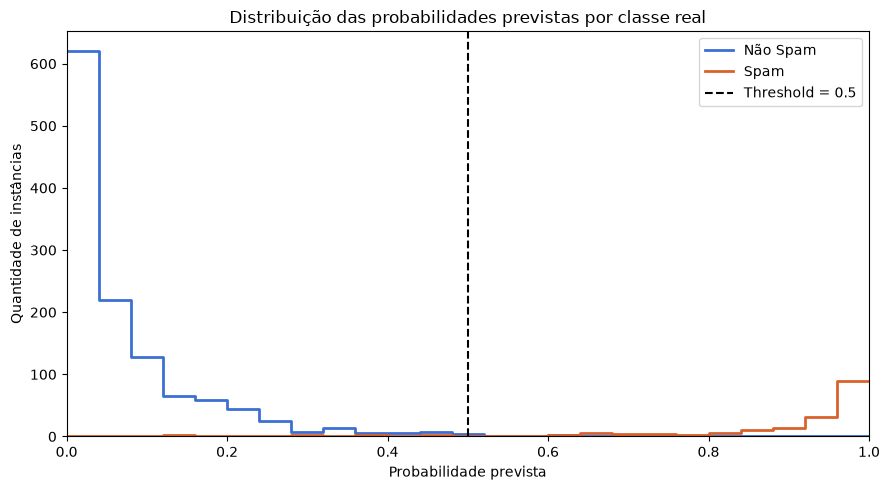

(<Figure size 900x500 with 1 Axes>,
 <Axes: title={'center': 'Distribuição das probabilidades previstas por classe real'}, xlabel='Probabilidade prevista', ylabel='Quantidade de instâncias'>)

In [ ]:
plot_histogram(y_test, y_prob_spam, threshold=0.5, class_labels=("Não Spam", "Spam"))